# Appendix A : GCM selection
Use the phd_v3 environment (can be replicated from the .yml file in envs/)

In [1]:
import xarray as xr
#import rioxarray as rxr
import xesmf as xe
import pandas as pd
import numpy as np
import calendar as cld
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
colors_land = plt.cm.terrain(np.linspace(0.25, 1, 256))
import proplot as pplt # New plot library (https://proplot.readthedocs.io/en/latest/)
pplt.rc['savefig.dpi'] = 300 # 1200 is too big! #https://proplot.readthedocs.io/en/latest/basics.html#Creating-figures
from scipy.stats import chi2
from numba import njit,prange
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.05  # previous pdf hatch linewidth
from matplotlib.dates import DateFormatter
from scipy import interpolate
from scipy import ndimage as ndi

from pyproj import CRS,Transformer,Proj

import sys
sys.path.insert(1, '/home/castelli/Notebooks/PhD/utils') # to include my util file in previous directory
import utils as u
u.check_python_version()

3.10.13 | packaged by conda-forge | (main, Oct 26 2023, 18:07:37) [GCC 12.3.0]


In [2]:
pplt.rc['figure.facecolor'] = 'white'


In [3]:
Model = ["EC-Earth3", "CESM2", "MPI-ESM1-2-HR", "MRI-ESM2-0", "UKESM1-0-LL",
         "BCC-CSM2-MR", "GFDL-ESM4", "MIROC6", "CAMS-CSM1-0", "GFDL-CM4",
         "NESM3", "CanESM5", "CNRM-ESM2-1", "FGOALS-g3", "CNRM-CM6-1",
         "IPSL-CM6A-LR"]

DJF = [-0.65, -0.8, -0.47, -0.37, -0.74, -0.16, -0.02, 0.24, 0.29, 0.45, 0.92, 1.16, -0.08, 0.68, 0.34, 0.65]
MAM = [-1.06, -0.7, -0.54, -0.1, -0.06, -0.16, -0.04, -0.2, -0.13, 0.4, 0.76, 0.63, 0.33, 0.1, 0.69, 1.1]
JJA = [-0.68, -0.01, 0.08, -0.59, 0.19, -0.2, -0.33, 0.31, 0.01, 0.12, 0.1, -0.41, 1.29, 0.73, 1.77, 1.31]
SON = [-0.9, -0.24, -0.62, -0.05, -0.37, -0.21, -0.11, 0.26, 0.53, 0.25, -0.2, 0.47, 0.55, 1.16, 0.93, 0.85]
Year = [-0.82, -0.44, -0.39, -0.28, -0.25, -0.18, -0.12, 0.15, 0.17, 0.31, 0.39, 0.46, 0.52, 0.67, 0.93, 0.98]

In [4]:
tab = pd.DataFrame({"Model": Model, "DJF": DJF, "MAM": MAM, "JJA": JJA, "SON": SON, "Year": Year})
print(tab)

            Model   DJF   MAM   JJA   SON  Year
0       EC-Earth3 -0.65 -1.06 -0.68 -0.90 -0.82
1           CESM2 -0.80 -0.70 -0.01 -0.24 -0.44
2   MPI-ESM1-2-HR -0.47 -0.54  0.08 -0.62 -0.39
3      MRI-ESM2-0 -0.37 -0.10 -0.59 -0.05 -0.28
4     UKESM1-0-LL -0.74 -0.06  0.19 -0.37 -0.25
5     BCC-CSM2-MR -0.16 -0.16 -0.20 -0.21 -0.18
6       GFDL-ESM4 -0.02 -0.04 -0.33 -0.11 -0.12
7          MIROC6  0.24 -0.20  0.31  0.26  0.15
8     CAMS-CSM1-0  0.29 -0.13  0.01  0.53  0.17
9        GFDL-CM4  0.45  0.40  0.12  0.25  0.31
10          NESM3  0.92  0.76  0.10 -0.20  0.39
11        CanESM5  1.16  0.63 -0.41  0.47  0.46
12    CNRM-ESM2-1 -0.08  0.33  1.29  0.55  0.52
13      FGOALS-g3  0.68  0.10  0.73  1.16  0.67
14     CNRM-CM6-1  0.34  0.69  1.77  0.93  0.93
15   IPSL-CM6A-LR  0.65  1.10  1.31  0.85  0.98


In [5]:
# styled = (
#     tab.style
#     #.format("{:.2f}")
#     .set_caption("Final mean normalised RMSE (half less weight for SST)")
#     .set_table_styles([
#         {'selector': 'th', 'props': [('font-weight', 'bold')]},
#         {'selector': 'caption', 'props': [('caption-side', 'bottom')]}
#     ])
# )

In [6]:
# styled.to_html("/bettik/castelli/figs/table_GCM_scores_Beaumet.html")

In [7]:
tab_formatted = tab.set_index("Model")

print("\n" + "="*53)
print("Final mean normalised RMSE (half less weight for SST)")
print("="*53)

print(tab_formatted.to_string())


Final mean normalised RMSE (half less weight for SST)
                DJF   MAM   JJA   SON  Year
Model                                      
EC-Earth3     -0.65 -1.06 -0.68 -0.90 -0.82
CESM2         -0.80 -0.70 -0.01 -0.24 -0.44
MPI-ESM1-2-HR -0.47 -0.54  0.08 -0.62 -0.39
MRI-ESM2-0    -0.37 -0.10 -0.59 -0.05 -0.28
UKESM1-0-LL   -0.74 -0.06  0.19 -0.37 -0.25
BCC-CSM2-MR   -0.16 -0.16 -0.20 -0.21 -0.18
GFDL-ESM4     -0.02 -0.04 -0.33 -0.11 -0.12
MIROC6         0.24 -0.20  0.31  0.26  0.15
CAMS-CSM1-0    0.29 -0.13  0.01  0.53  0.17
GFDL-CM4       0.45  0.40  0.12  0.25  0.31
NESM3          0.92  0.76  0.10 -0.20  0.39
CanESM5        1.16  0.63 -0.41  0.47  0.46
CNRM-ESM2-1   -0.08  0.33  1.29  0.55  0.52
FGOALS-g3      0.68  0.10  0.73  1.16  0.67
CNRM-CM6-1     0.34  0.69  1.77  0.93  0.93
IPSL-CM6A-LR   0.65  1.10  1.31  0.85  0.98


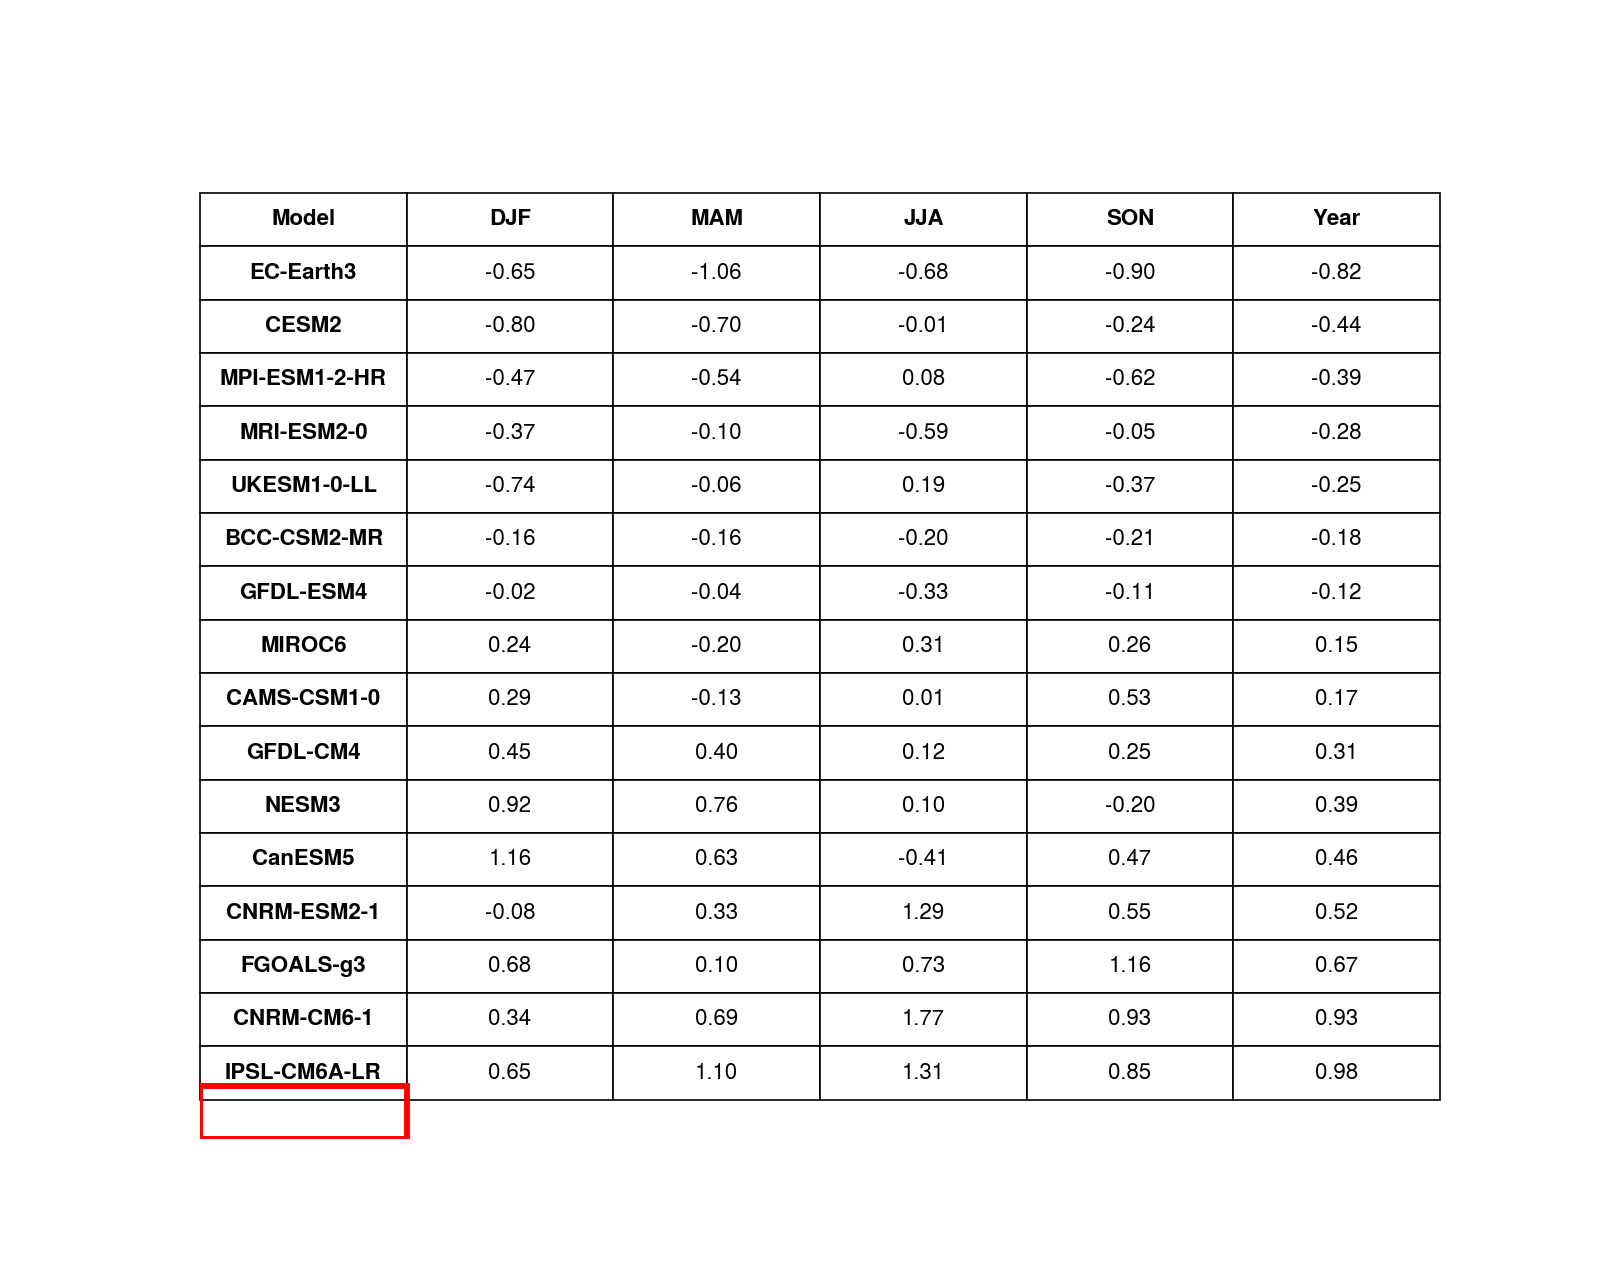

In [31]:
# ---------------------- Drawing the table ---------------------

import matplotlib.patheffects as path_effects
from matplotlib.patches import Rectangle

cell_text = []
for _, row in tab.iterrows():
    cell_text.append([
        row["Model"],
        f"{row['DJF']:.2f}",
        f"{row['MAM']:.2f}",
        f"{row['JJA']:.2f}",
        f"{row['SON']:.2f}",
        f"{row['Year']:.2f}",
    ])

col_labels = ["Model", "DJF", "MAM", "JJA", "SON", "Year"]

fig, ax = plt.subplots(figsize=(8, 0.4*len(tab)))

table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    loc="center",
    cellLoc="center"
)

ax.axis("off")
table.scale(1, 1.6)

# cmap = plt.cm.RdBu_r  # or your "hot_r"
# norm = mcolors.Normalize(
#     vmin=tab.iloc[:,1:].min().min(),
#     vmax=tab.iloc[:,1:].max().max()
# )

# for i in range(len(tab)):
#     values = tab.iloc[i, 1:]  # all except "Model"
    
#     for j, val in enumerate(values, start=1):
#         cell = table[(i+1, j)]
#         cell.set_facecolor(cmap(norm(val)))
        
#         # Text styling (halo effect)
#         txt = cell.get_text()
#         txt.set_color('black')
#         txt.set_fontweight('bold')
#         txt.set_path_effects([
#             path_effects.Stroke(linewidth=1.2, foreground='white'),
#             path_effects.Normal()
#         ])

# Header bold
for j in range(len(col_labels)):
    table[(0, j)].get_text().set_fontweight('bold')

# Model column bold
for i in range(len(tab)):
    table[(i+1, 0)].get_text().set_fontweight('bold')


groups = [(1,2), (2,3)]  # rows to highlight

for row_start, row_end in groups:
    top_cell = table[(row_start, 0)]
    bottom_cell = table[(row_end, 0)]
    
    x_left = top_cell.get_x()
    y_top = top_cell.get_y() + top_cell.get_height()
    y_bottom = bottom_cell.get_y()
    
    x_right = table[(row_start, len(col_labels)-1)].get_x() + \
              table[(row_start, len(col_labels)-1)].get_width()
    
    rect = Rectangle(
        (x_left, y_bottom),
        x_right - x_left,
        y_top - y_bottom,
        fill=False,
        edgecolor='red',
        linewidth=2,
        transform=ax.transAxes
    )
    
    ax.add_patch(rect)

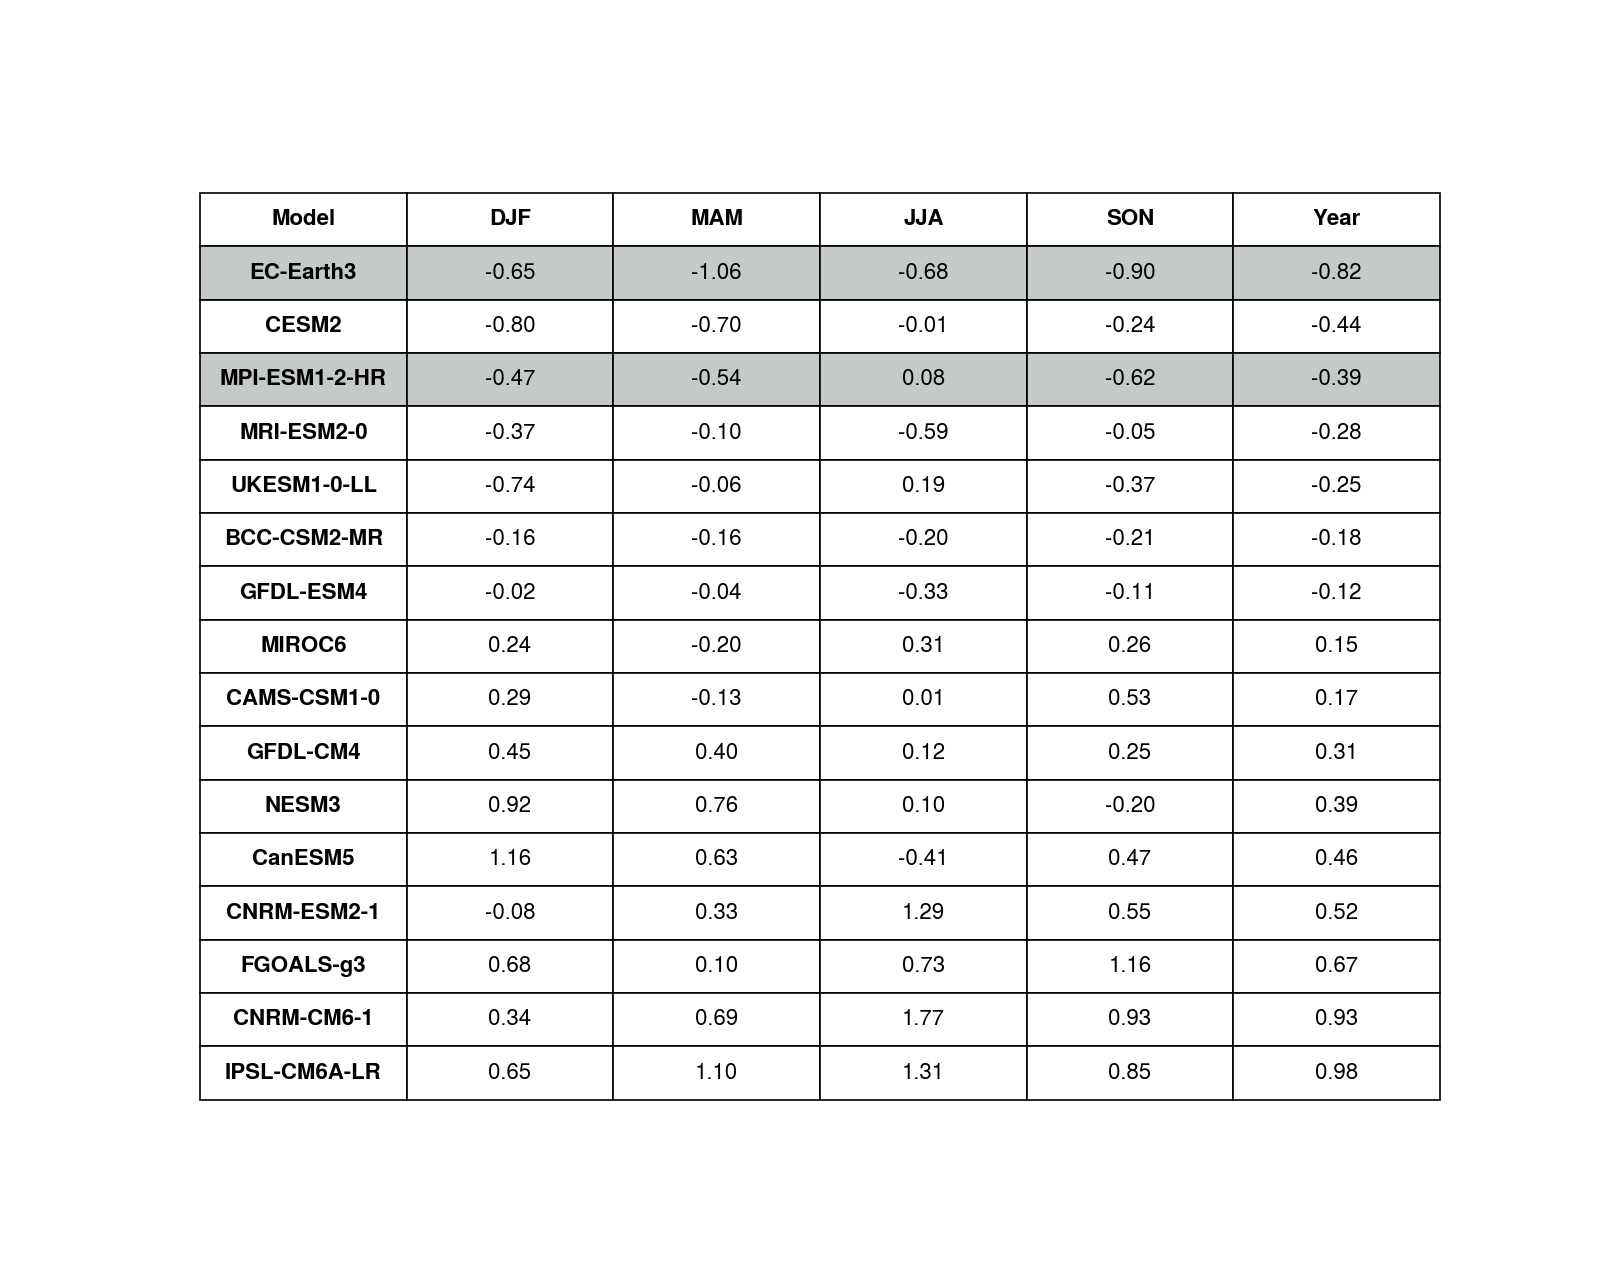

In [10]:
# ---------------------- Drawing the table ---------------------

import matplotlib.patheffects as path_effects
from matplotlib.patches import Rectangle

cell_text = []
for _, row in tab.iterrows():
    cell_text.append([
        row["Model"],
        f"{row['DJF']:.2f}",
        f"{row['MAM']:.2f}",
        f"{row['JJA']:.2f}",
        f"{row['SON']:.2f}",
        f"{row['Year']:.2f}",
    ])

col_labels = ["Model", "DJF", "MAM", "JJA", "SON", "Year"]

fig, ax = plt.subplots(figsize=(8, 0.4*len(tab)))

table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    loc="center",
    cellLoc="center"
)

ax.axis("off")
table.scale(1, 1.6)

# cmap = plt.cm.RdBu_r  # or your "hot_r"
# norm = mcolors.Normalize(
#     vmin=tab.iloc[:,1:].min().min(),
#     vmax=tab.iloc[:,1:].max().max()
# )

# for i in range(len(tab)):
#     values = tab.iloc[i, 1:]  # all except "Model"
    
#     for j, val in enumerate(values, start=1):
#         cell = table[(i+1, j)]
#         cell.set_facecolor(cmap(norm(val)))
        
#         # Text styling (halo effect)
#         txt = cell.get_text()
#         txt.set_color('black')
#         txt.set_fontweight('bold')
#         txt.set_path_effects([
#             path_effects.Stroke(linewidth=1.2, foreground='white'),
#             path_effects.Normal()
#         ])

# Header bold
for j in range(len(col_labels)):
    table[(0, j)].get_text().set_fontweight('bold')

# Model column bold
for i in range(len(tab)):
    table[(i+1, 0)].get_text().set_fontweight('bold')

from matplotlib.transforms import Bbox

fig.canvas.draw()

groups = [(1,1), (3,3)]

for row_start, row_end in groups:
    for i in range(row_start, row_end + 1):
        for j in range(len(col_labels)):
            cell = table[(i, j)]
            # cell.set_facecolor("#f0f0f0")  # light grey
            cell.set_facecolor("silver")  # light grey

fig.savefig("/bettik/castelli/figs/EDW_final_figs/fA1.png", dpi=300)
# for row_start, row_end in groups:
#     # Get bounding boxes of top-left and bottom-right cells
#     cell_tl = table[(row_start, 0)]
#     cell_br = table[(row_end, len(col_labels)-1)]

#     bbox_tl = cell_tl.get_window_extent(fig.canvas.get_renderer())
#     bbox_br = cell_br.get_window_extent(fig.canvas.get_renderer())

#     # Combine into one bbox
#     bbox = Bbox.from_extents(
#         bbox_tl.x0,  # left
#         bbox_br.y0,  # bottom
#         bbox_br.x1,  # right
#         bbox_tl.y1   # top
#     )

#     # Transform from display → axes coordinates
#     bbox_axes = bbox.transformed(ax.transAxes.inverted())

#     # Draw rectangle
#     rect = Rectangle(
#         (bbox_axes.x0, bbox_axes.y0),
#         bbox_axes.width,
#         bbox_axes.height,
#         fill=False,
#         edgecolor='red',
#         linewidth=2,
#         transform=ax.transAxes
#     )

#     ax.add_patch(rect)